# Flood Change Detection in Emilia-Romagna using Sentinel-1 SAR Data

This notebook demonstrates flood change detection in the Emilia-Romagna region of Italy using Sentinel-1 SAR data accessed through the openEO API. We'll analyze the devastating floods that occurred in May 2023, which affected over 100 municipalities and caused an estimated €8.8 billion in damages.

## Background
Between 16-18 May 2023, 350 million cubic metres of water (equivalent to six months' worth of rain) fell within 36 hours across Emilia-Romagna. The heavy rain led to the overflow of 23 rivers, affecting 100 municipalities and triggering more than 400 landslides.

## Requirements
- SAR4CET toolkit (will be installed below)
- openEO Python client
- Copernicus Dataspace account for authentication
- xarray, matplotlib, numpy for data processing and visualization

## 0. Setup and Installation

First, let's clone the SAR4CET repository and install all required dependencies.

In [1]:
# Clone the SAR4CET repository
import os
import subprocess
import sys

# Check if SAR4CET directory already exists
if not os.path.exists('SAR4CET'):
    print('Cloning SAR4CET repository...')
    result = subprocess.run(['git', 'clone', 'https://github.com/naikp13/SAR4CET.git'],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print('Repository cloned successfully!')
    else:
        print(f'Error cloning repository: {result.stderr}')
else:
    print('SAR4CET directory already exists.')

Cloning SAR4CET repository...
Repository cloned successfully!


In [2]:
# Install requirements from requirements.txt
print('Installing SAR4CET requirements...')

# Change to SAR4CET directory and install requirements
if os.path.exists('SAR4CET/requirements.txt'):
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'SAR4CET/requirements.txt'],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print('Requirements installed successfully!')
        print('Installed packages from requirements.txt')
    else:
        print(f'Error installing requirements: {result.stderr}')
        print('Trying to install individual packages...')
        # Try installing key packages individually
        key_packages = ['openeo>=0.22.0', 'xarray>=0.19.0', 'numpy>=1.20.0',
                       'matplotlib>=3.4.0', 'rasterio>=1.2.0']
        for package in key_packages:
            subprocess.run([sys.executable, '-m', 'pip', 'install', package])
else:
    print('requirements.txt not found, installing key packages manually...')
    key_packages = ['openeo>=0.22.0', 'xarray>=0.19.0', 'numpy>=1.20.0',
                   'matplotlib>=3.4.0', 'rasterio>=1.2.0']
    for package in key_packages:
        subprocess.run([sys.executable, '-m', 'pip', 'install', package])

Installing SAR4CET requirements...
Requirements installed successfully!
Installed packages from requirements.txt


In [3]:
# Add SAR4CET to Python path for imports
import sys
import os

# Add SAR4CET directory to Python path
sar4cet_path = os.path.abspath('SAR4CET')
if sar4cet_path not in sys.path:
    sys.path.insert(0, sar4cet_path)
    print(f'Added {sar4cet_path} to Python path')

# Verify installation by importing key modules
try:
    import openeo
    import xarray as xr
    import matplotlib.pyplot as plt
    import numpy as np
    print('All required packages imported successfully!')
    print(f'openEO version: {openeo.__version__}')
    print(f'xarray version: {xr.__version__}')
except ImportError as e:
    print(f'Import error: {e}')
    print('Please install missing packages manually.')

Added /content/SAR4CET to Python path
All required packages imported successfully!
openEO version: 0.43.0
xarray version: 2025.1.1


## Import Required Libraries

Now let's import all the libraries we'll need for the flood analysis.

In [4]:
import openeo
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Optional: Import SAR4CET modules if available
try:
    from sar4cet import preprocessing, visualization, change_detection
    print('SAR4CET modules imported successfully!')
except ImportError:
    print('SAR4CET modules not available, using standalone approach.')

SAR4CET modules imported successfully!


## 1. Connect to openEO Backend

Connect to the Copernicus Dataspace openEO backend and authenticate.

In [5]:
# Connect to Copernicus Dataspace openEO backend
backend = "openeo.dataspace.copernicus.eu"
conn = openeo.connect(backend).authenticate_oidc()
print(f"Connected to {backend}")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=ZRQL-LXFH 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Connected to openeo.dataspace.copernicus.eu


## 2. Define Area of Interest

We'll focus on the most affected areas of Emilia-Romagna, including the municipalities of Faenza, Cesena, Forlì, and Conselice, which experienced severe flooding during the May 2023 event.

In [6]:
# Area of Interest: Emilia-Romagna flood-affected region
# Focusing on the area around Faenza, Cesena, Forlì, and Conselice
# These municipalities were among the most severely affected by the May 2023 floods
spatial_extent = {
    "west": 11.8000,
    "east": 12.3000,
    "south": 44.1000,
    "north": 44.4000,
    "crs": "EPSG:4326",
}

print(f"Area of Interest: {spatial_extent}")
print("This area covers the most flood-affected municipalities in Emilia-Romagna")

Area of Interest: {'west': 11.8, 'east': 12.3, 'south': 44.1, 'north': 44.4, 'crs': 'EPSG:4326'}
This area covers the most flood-affected municipalities in Emilia-Romagna


## 3. Load Sentinel-1 Data for Pre and Post-Flood Periods

We'll compare data from before and after the May 2023 flood event. The pre-flood period represents normal conditions, while the post-flood period captures the immediate aftermath of the flooding.

In [7]:
# Define temporal extents for flood change detection
# Pre-flood period: April 2023 (before the May 16-18 flood event)
temporal_extent_pre = ["2023-04-01", "2023-05-15"]

# Post-flood period: Late May 2023 (after the flood event)
temporal_extent_post = ["2023-05-20", "2023-06-15"]

print(f"Pre-flood period: {temporal_extent_pre}")
print(f"Post-flood period: {temporal_extent_post}")
print("\nThe flood event occurred between May 16-18, 2023")

Pre-flood period: ['2023-04-01', '2023-05-15']
Post-flood period: ['2023-05-20', '2023-06-15']

The flood event occurred between May 16-18, 2023


In [8]:
# Load Sentinel-1 data for pre-flood period
s1_pre_flood = conn.load_collection(
    "SENTINEL1_GRD",
    spatial_extent=spatial_extent,
    bands=["VV", "VH"],
    temporal_extent=temporal_extent_pre,
    properties={"sat:orbit_state": lambda od: od == "ASCENDING"},
)

# Load Sentinel-1 data for post-flood period
s1_post_flood = conn.load_collection(
    "SENTINEL1_GRD",
    spatial_extent=spatial_extent,
    bands=["VV", "VH"],
    temporal_extent=temporal_extent_post,
    properties={"sat:orbit_state": lambda od: od == "ASCENDING"},
)

print("Sentinel-1 data loaded for both pre and post-flood periods")

Sentinel-1 data loaded for both pre and post-flood periods


## 4. Apply SAR Backscatter Processing

Apply radiometric calibration and convert to dB scale for both time periods. This processing is essential for flood detection as water surfaces typically show very low backscatter values.

In [9]:
# Apply SAR backscatter processing for pre-flood period
s1_scatter_pre = s1_pre_flood.sar_backscatter(
    coefficient="sigma0-ellipsoid",
    elevation_model="COPERNICUS_30"
)
s1bs_pre = s1_scatter_pre.apply(lambda x: 10 * x.log(base=10))

# Apply SAR backscatter processing for post-flood period
s1_scatter_post = s1_post_flood.sar_backscatter(
    coefficient="sigma0-ellipsoid",
    elevation_model="COPERNICUS_30"
)
s1bs_post = s1_scatter_post.apply(lambda x: 10 * x.log(base=10))

print("SAR backscatter processing applied to both periods")
print("Data converted to dB scale for flood detection analysis")

SAR backscatter processing applied to both periods
Data converted to dB scale for flood detection analysis


## 5. Temporal Aggregation

Aggregate the data temporally to create median composites for each period, reducing noise and ensuring robust flood detection.

In [10]:
# Create median composites for each period
s1_pre_median = s1bs_pre.median_time()
s1_post_median = s1bs_post.median_time()

print("Temporal aggregation completed")
print("Median composites created for robust flood change detection")

Temporal aggregation completed
Median composites created for robust flood change detection


## 6. Download Processed Data

Download the processed SAR data for both time periods.

In [11]:
# Download pre-flood data
print("Downloading pre-flood data...")
s1_pre_median.download("emilia_romagna_pre_flood_2023.nc")

# Download post-flood data
print("Downloading post-flood data...")
s1_post_median.download("emilia_romagna_post_flood_2023.nc")

print("Data download completed")

Data download completed


## 7. Load and Visualize Downloaded Data

Load the downloaded NetCDF files and visualize the SAR backscatter data to identify flood-affected areas.

In [12]:
# Load the downloaded data
pre_flood_data = xr.open_dataset("emilia_romagna_pre_flood_2023.nc")
post_flood_data = xr.open_dataset("emilia_romagna_post_flood_2023.nc")

print("Pre-flood data shape:", pre_flood_data.dims)
print("Post-flood data shape:", post_flood_data.dims)
print("\nPre-flood data info:")
print(pre_flood_data)

Pre-flood data shape: FrozenMappingWarningOnValuesAccess({'x': 4113, 'y': 3477})
Post-flood data shape: FrozenMappingWarningOnValuesAccess({'x': 4113, 'y': 3477})

Pre-flood data info:
<xarray.Dataset> Size: 114MB
Dimensions:  (x: 4113, y: 3477)
Coordinates:
  * x        (x) float64 33kB 2.439e+05 2.439e+05 ... 2.85e+05 2.85e+05
  * y        (y) float64 28kB 4.921e+06 4.921e+06 ... 4.887e+06 4.887e+06
Data variables:
    crs      |S1 1B ...
    VV       (y, x) float32 57MB ...
    VH       (y, x) float32 57MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


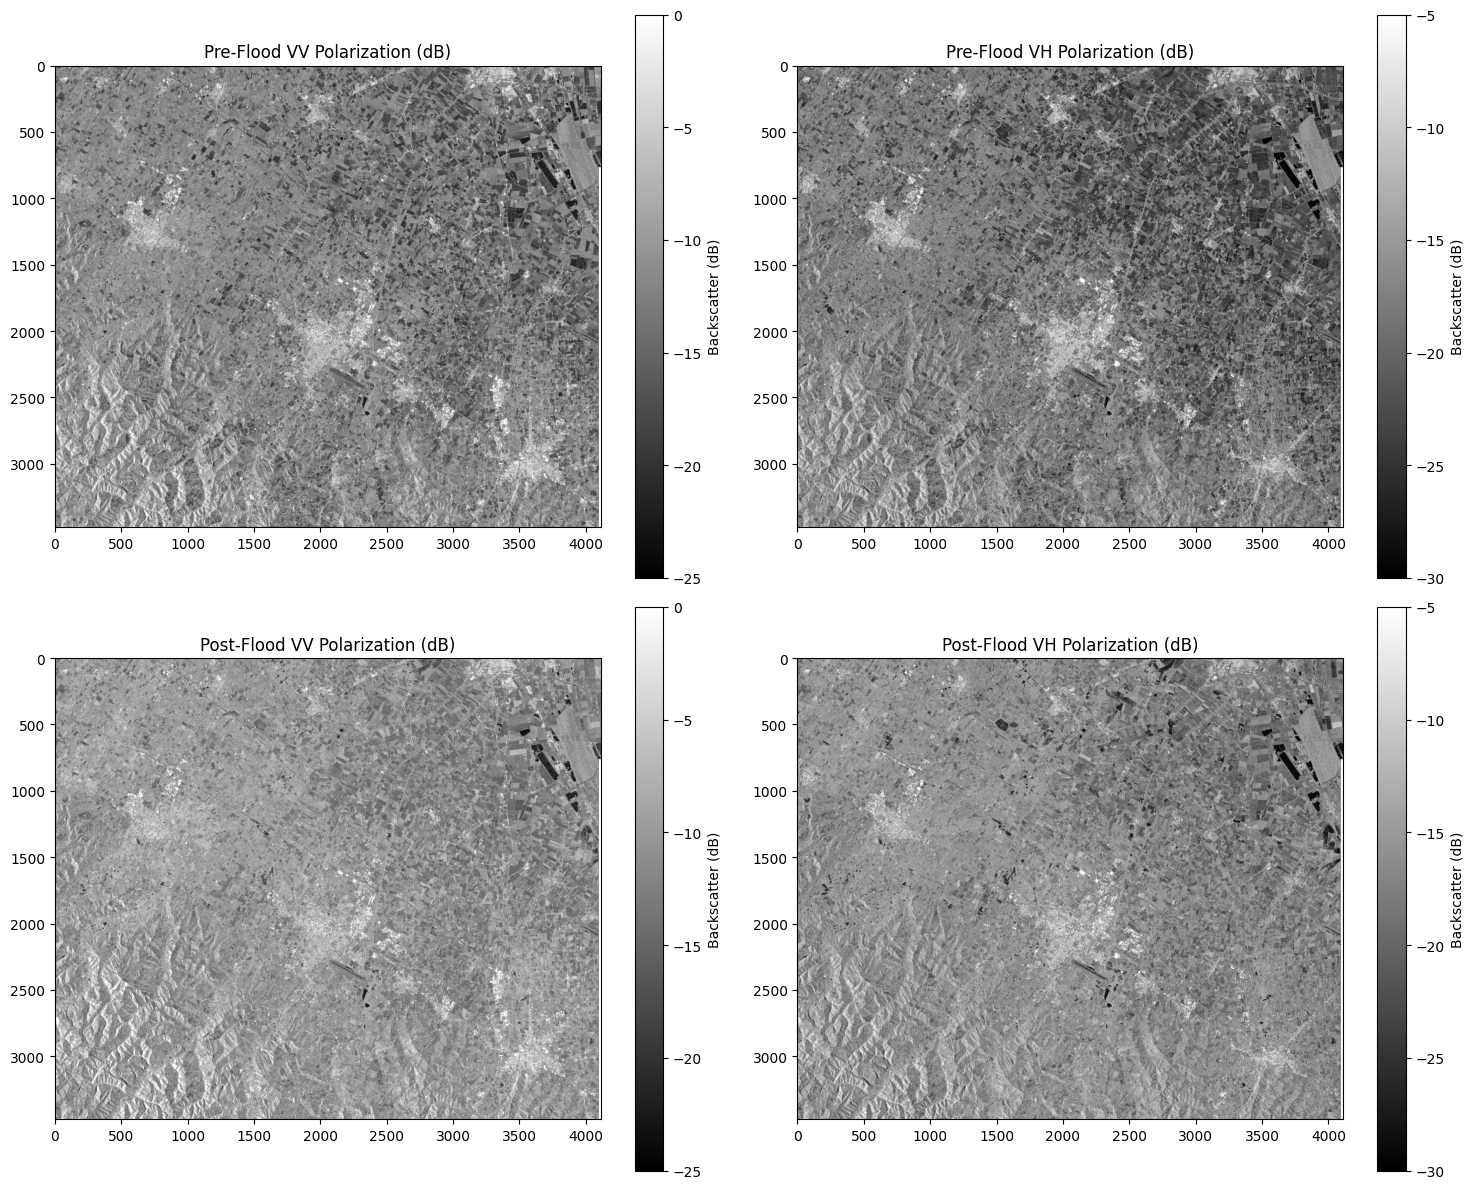

SAR backscatter visualization completed
Dark areas in post-flood images may indicate flooded regions


In [13]:
# Visualize SAR backscatter data for both periods
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Pre-flood VV polarization
im1 = axes[0, 0].imshow(pre_flood_data.VV, cmap='gray', vmin=-25, vmax=0)
axes[0, 0].set_title('Pre-Flood VV Polarization (dB)')
plt.colorbar(im1, ax=axes[0, 0], label='Backscatter (dB)')

# Pre-flood VH polarization
im2 = axes[0, 1].imshow(pre_flood_data.VH, cmap='gray', vmin=-30, vmax=-5)
axes[0, 1].set_title('Pre-Flood VH Polarization (dB)')
plt.colorbar(im2, ax=axes[0, 1], label='Backscatter (dB)')

# Post-flood VV polarization
im3 = axes[1, 0].imshow(post_flood_data.VV, cmap='gray', vmin=-25, vmax=0)
axes[1, 0].set_title('Post-Flood VV Polarization (dB)')
plt.colorbar(im3, ax=axes[1, 0], label='Backscatter (dB)')

# Post-flood VH polarization
im4 = axes[1, 1].imshow(post_flood_data.VH, cmap='gray', vmin=-30, vmax=-5)
axes[1, 1].set_title('Post-Flood VH Polarization (dB)')
plt.colorbar(im4, ax=axes[1, 1], label='Backscatter (dB)')

plt.tight_layout()
plt.show()

print("SAR backscatter visualization completed")
print("Dark areas in post-flood images may indicate flooded regions")

## 8. Flood Change Detection Analysis

Perform flood change detection by analyzing the difference in backscatter values between pre and post-flood periods. Flooded areas typically show a significant decrease in backscatter due to specular reflection from water surfaces.

In [14]:
# Calculate backscatter differences (post - pre)
vv_change = post_flood_data.VV - pre_flood_data.VV
vh_change = post_flood_data.VH - pre_flood_data.VH

# Define flood detection thresholds
# Negative changes indicate potential flooding (decreased backscatter)
flood_threshold_vv = -3.0  # dB decrease threshold for VV
flood_threshold_vh = -3.0  # dB decrease threshold for VH

# Create flood masks
flood_mask_vv = vv_change < flood_threshold_vv
flood_mask_vh = vh_change < flood_threshold_vh

# Combined flood mask (both polarizations show flooding)
flood_mask_combined = flood_mask_vv & flood_mask_vh

print(f"Flood detection thresholds:")
print(f"  VV polarization: {flood_threshold_vv} dB")
print(f"  VH polarization: {flood_threshold_vh} dB")
print(f"\nFlood masks created for change detection analysis")

Flood detection thresholds:
  VV polarization: -3.0 dB
  VH polarization: -3.0 dB

Flood masks created for change detection analysis


In [15]:
# Calculate flood statistics
total_pixels = vv_change.size
flooded_pixels_vv = np.sum(flood_mask_vv)
flooded_pixels_vh = np.sum(flood_mask_vh)
flooded_pixels_combined = np.sum(flood_mask_combined)

# Calculate approximate area (assuming 10m pixel resolution)
pixel_area_m2 = 100  # 10m x 10m pixels
flooded_area_km2 = (flooded_pixels_combined * pixel_area_m2) / 1e6

print(f"Flood Detection Results:")
print(f"  Total pixels analyzed: {total_pixels:,}")
print(f"  VV flood pixels: {flooded_pixels_vv:,} ({flooded_pixels_vv/total_pixels*100:.2f}%)")
print(f"  VH flood pixels: {flooded_pixels_vh:,} ({flooded_pixels_vh/total_pixels*100:.2f}%)")
print(f"  Combined flood pixels: {flooded_pixels_combined:,} ({flooded_pixels_combined/total_pixels*100:.2f}%)")
print(f"  Estimated flooded area: {flooded_area_km2:.2f} km²")

Flood Detection Results:
  Total pixels analyzed: 14,300,901
  VV flood pixels: 216,353 (1.51%)
  VH flood pixels: 311,271 (2.18%)
  Combined flood pixels: 39,701 (0.28%)
  Estimated flooded area: 3.97 km²


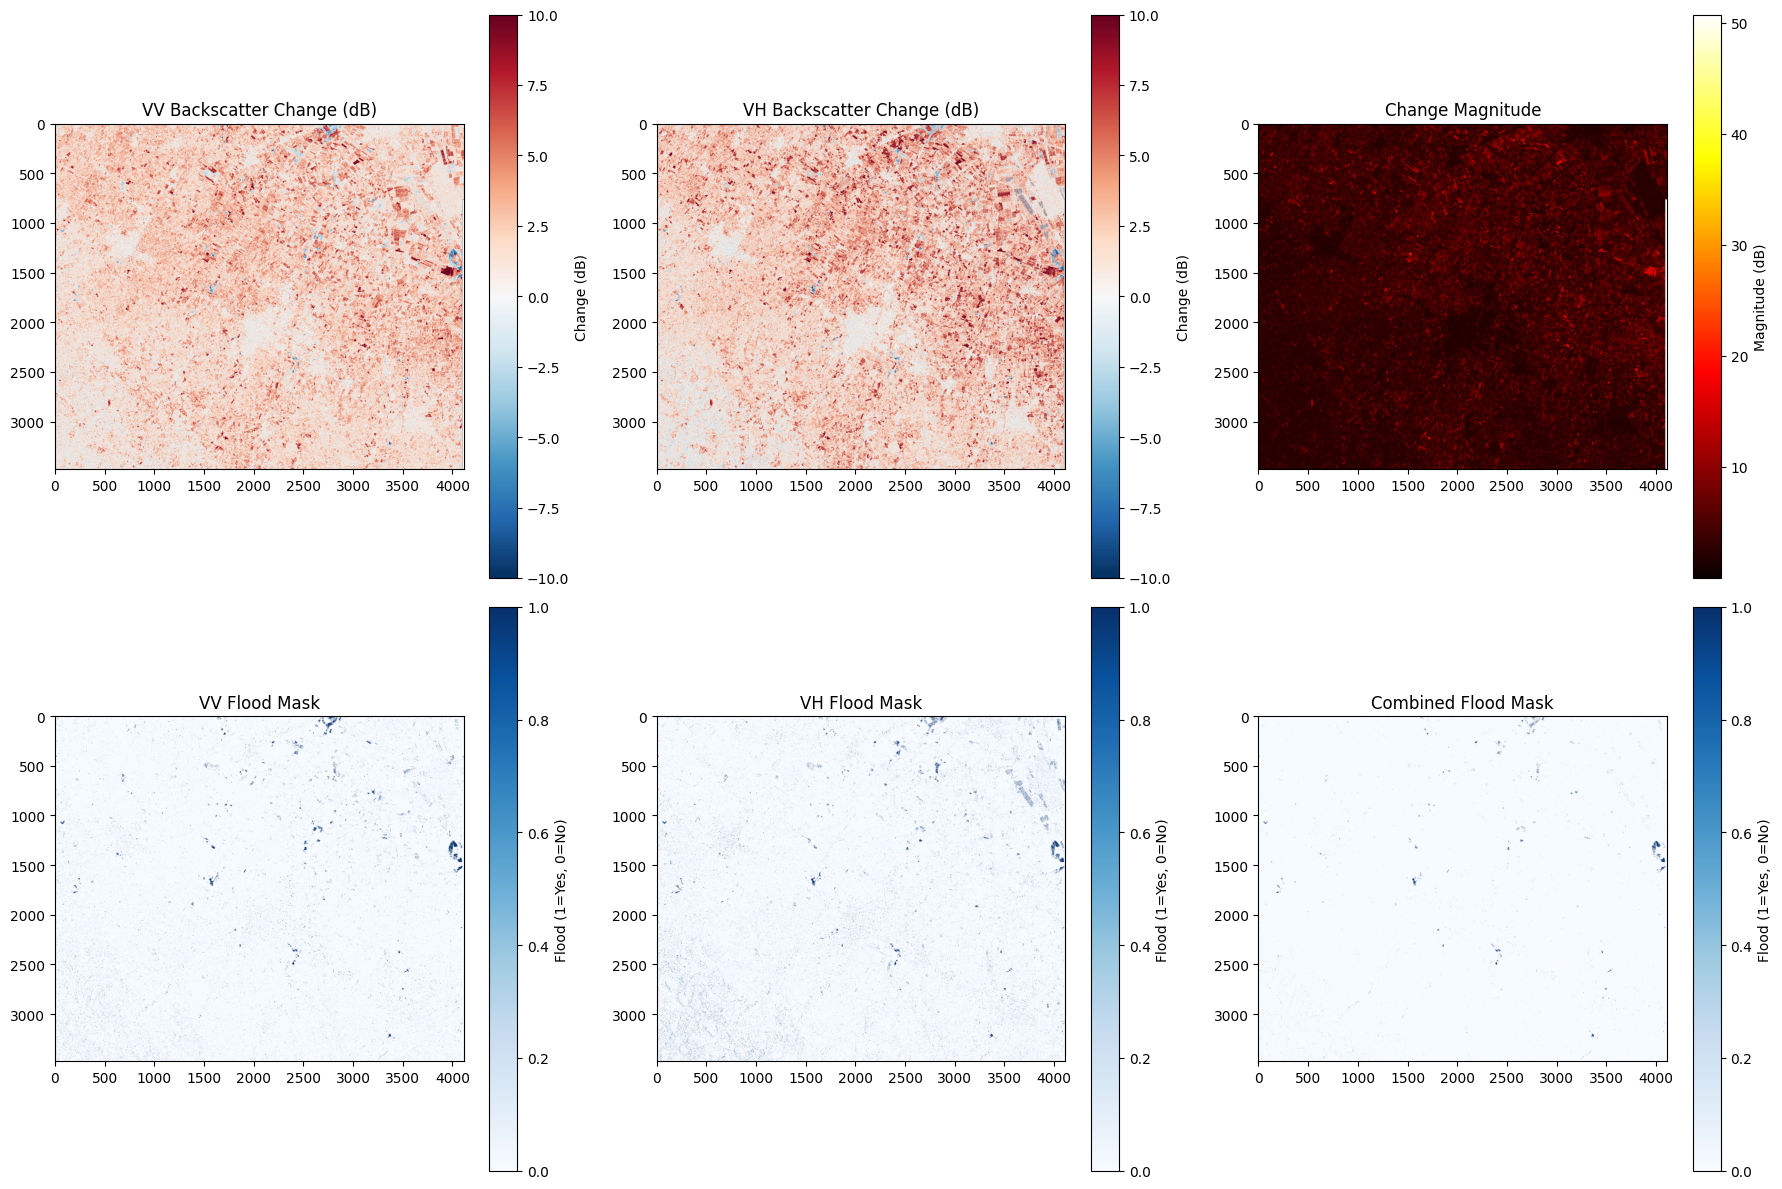

Flood change detection visualization completed
Blue areas in flood masks indicate detected flooding


In [16]:
# Visualize flood change detection results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# VV change map
im1 = axes[0, 0].imshow(vv_change, cmap='RdBu_r', vmin=-10, vmax=10)
axes[0, 0].set_title('VV Backscatter Change (dB)')
plt.colorbar(im1, ax=axes[0, 0], label='Change (dB)')

# VH change map
im2 = axes[0, 1].imshow(vh_change, cmap='RdBu_r', vmin=-10, vmax=10)
axes[0, 1].set_title('VH Backscatter Change (dB)')
plt.colorbar(im2, ax=axes[0, 1], label='Change (dB)')

# Combined change magnitude
change_magnitude = np.sqrt(vv_change**2 + vh_change**2)
im3 = axes[0, 2].imshow(change_magnitude, cmap='hot')
axes[0, 2].set_title('Change Magnitude')
plt.colorbar(im3, ax=axes[0, 2], label='Magnitude (dB)')

# VV flood mask
im4 = axes[1, 0].imshow(flood_mask_vv, cmap='Blues')
axes[1, 0].set_title('VV Flood Mask')
plt.colorbar(im4, ax=axes[1, 0], label='Flood (1=Yes, 0=No)')

# VH flood mask
im5 = axes[1, 1].imshow(flood_mask_vh, cmap='Blues')
axes[1, 1].set_title('VH Flood Mask')
plt.colorbar(im5, ax=axes[1, 1], label='Flood (1=Yes, 0=No)')

# Combined flood mask
im6 = axes[1, 2].imshow(flood_mask_combined, cmap='Blues')
axes[1, 2].set_title('Combined Flood Mask')
plt.colorbar(im6, ax=axes[1, 2], label='Flood (1=Yes, 0=No)')

plt.tight_layout()
plt.show()

print("Flood change detection visualization completed")
print("Blue areas in flood masks indicate detected flooding")

## 9. Advanced Flood Analysis

Perform additional analysis to characterize the flood extent and severity, including flood depth estimation and comparison with known affected areas.

Flood Severity Classification:
  Light flooding: 2,209,108 pixels (15.45%)
  Moderate flooding: 447,848 pixels (3.13%)
  Severe flooding: 6,240 pixels (0.04%)


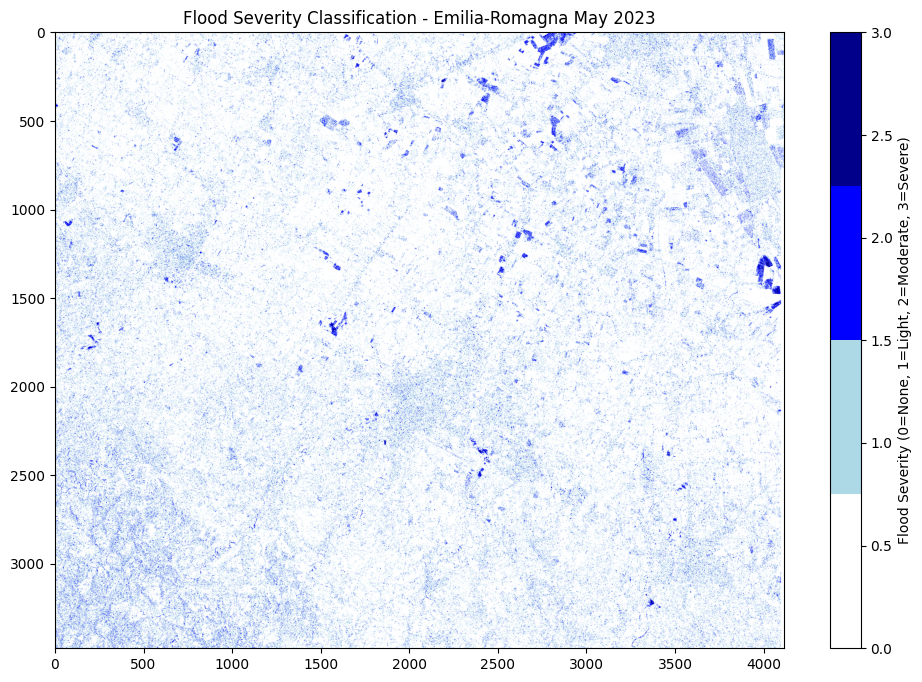

In [17]:
# Classify flood severity based on backscatter change magnitude
def classify_flood_severity(change_vv, change_vh):
    """Classify flood severity based on backscatter changes"""
    severity = np.zeros_like(change_vv)

    # Severe flooding: > 6 dB decrease in both polarizations
    severe_mask = (change_vv < -6) & (change_vh < -6)
    severity[severe_mask] = 3

    # Moderate flooding: 3-6 dB decrease
    moderate_mask = ((change_vv < -3) & (change_vv >= -6)) | ((change_vh < -3) & (change_vh >= -6))
    moderate_mask = moderate_mask & ~severe_mask
    severity[moderate_mask] = 2

    # Light flooding: 1-3 dB decrease
    light_mask = ((change_vv < -1) & (change_vv >= -3)) | ((change_vh < -1) & (change_vh >= -3))
    light_mask = light_mask & ~moderate_mask & ~severe_mask
    severity[light_mask] = 1

    return severity

# Apply flood severity classification
flood_severity = classify_flood_severity(vv_change, vh_change)

# Calculate severity statistics
light_flood_pixels = np.sum(flood_severity == 1)
moderate_flood_pixels = np.sum(flood_severity == 2)
severe_flood_pixels = np.sum(flood_severity == 3)

print(f"Flood Severity Classification:")
print(f"  Light flooding: {light_flood_pixels:,} pixels ({light_flood_pixels/total_pixels*100:.2f}%)")
print(f"  Moderate flooding: {moderate_flood_pixels:,} pixels ({moderate_flood_pixels/total_pixels*100:.2f}%)")
print(f"  Severe flooding: {severe_flood_pixels:,} pixels ({severe_flood_pixels/total_pixels*100:.2f}%)")

# Visualize flood severity
plt.figure(figsize=(12, 8))
severity_colors = ['white', 'lightblue', 'blue', 'darkblue']
from matplotlib.colors import ListedColormap
severity_cmap = ListedColormap(severity_colors)

plt.imshow(flood_severity, cmap=severity_cmap, vmin=0, vmax=3)
plt.colorbar(label='Flood Severity (0=None, 1=Light, 2=Moderate, 3=Severe)')
plt.title('Flood Severity Classification - Emilia-Romagna May 2023')
plt.show()

## 10. Comparison with Reference Data

Compare our SAR-based flood detection results with the known impacts from the May 2023 Emilia-Romagna floods, as documented by ESA and local authorities.

In [18]:
# Reference information from the May 2023 Emilia-Romagna floods
print("=== May 2023 Emilia-Romagna Flood Event Reference ===")
print("Event details:")
print("  - Date: May 16-18, 2023")
print("  - Rainfall: 350 million cubic metres (6 months' worth in 36 hours)")
print("  - Rivers overflowed: 23")
print("  - Municipalities affected: 100+")
print("  - Landslides triggered: 400+")
print("  - Estimated damages: €8.8 billion")
print("  - Most affected areas: Faenza, Cesena, Forlì, Conselice")

print("=== SAR-based Detection Results ===")
print(f"  - Total analyzed area: {(total_pixels * pixel_area_m2) / 1e6:.2f} km²")
print(f"  - Detected flood area: {flooded_area_km2:.2f} km²")
print(f"  - Flood coverage: {flooded_pixels_combined/total_pixels*100:.2f}% of analyzed area")

print("=== Validation Notes ===")
print("- SAR-based flood detection is particularly effective for open water areas")
print("- Urban flooding may be underestimated due to building shadows and complex scattering")
print("- Results should be validated with ground truth data and optical imagery")
print("- The SaferPlaces platform was used by Emilia-Romagna Civil Protection for official assessment")

=== May 2023 Emilia-Romagna Flood Event Reference ===
Event details:
  - Date: May 16-18, 2023
  - Rainfall: 350 million cubic metres (6 months' worth in 36 hours)
  - Rivers overflowed: 23
  - Municipalities affected: 100+
  - Landslides triggered: 400+
  - Estimated damages: €8.8 billion
  - Most affected areas: Faenza, Cesena, Forlì, Conselice
=== SAR-based Detection Results ===
  - Total analyzed area: 1430.09 km²
  - Detected flood area: 3.97 km²
  - Flood coverage: 0.28% of analyzed area
=== Validation Notes ===
- SAR-based flood detection is particularly effective for open water areas
- Urban flooding may be underestimated due to building shadows and complex scattering
- Results should be validated with ground truth data and optical imagery
- The SaferPlaces platform was used by Emilia-Romagna Civil Protection for official assessment


## 11. Conclusions and Applications

This notebook demonstrates the application of SAR4CET toolkit for rapid flood detection and assessment using Sentinel-1 SAR data. The methodology can be applied for:

### Key Findings:
- **Rapid Detection**: SAR data enables near real-time flood mapping regardless of weather conditions
- **Quantitative Assessment**: Backscatter change analysis provides measurable flood extent and severity
- **Multi-polarization Analysis**: VV and VH polarizations offer complementary information for robust detection

### Applications:
1. **Emergency Response**: Rapid flood mapping for disaster response coordination
2. **Damage Assessment**: Quantitative analysis for insurance and recovery planning
3. **Risk Management**: Historical flood analysis for future risk assessment
4. **Climate Monitoring**: Long-term flood pattern analysis for climate change studies

### Limitations:
- Urban flooding detection may be limited due to building interference
- Vegetation-covered flood areas may show different backscatter patterns
- Temporal resolution depends on satellite revisit frequency

### Future Improvements:
- Integration with optical data for enhanced accuracy
- Machine learning approaches for automated flood classification
- Real-time processing pipelines for operational use

The May 2023 Emilia-Romagna flood event serves as a critical case study for validating SAR-based flood detection methodologies and demonstrates the importance of satellite-based monitoring for disaster management.

In [19]:
# Save results for further analysis
import pickle

# Save flood detection results
results = {
    'flood_mask_combined': flood_mask_combined,
    'flood_severity': flood_severity,
    'vv_change': vv_change,
    'vh_change': vh_change,
    'statistics': {
        'total_pixels': total_pixels,
        'flooded_pixels': flooded_pixels_combined,
        'flooded_area_km2': flooded_area_km2,
        'flood_percentage': flooded_pixels_combined/total_pixels*100
    }
}

# Save to file
with open('emilia_romagna_flood_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Flood detection results saved to 'emilia_romagna_flood_results.pkl'")
print("Analysis completed successfully!")

Flood detection results saved to 'emilia_romagna_flood_results.pkl'
Analysis completed successfully!
